In [1]:
# Environment setup
import os
IS_KAGGLE = os.path.exists('/kaggle')
if IS_KAGGLE:
    print('Running on Kaggle')
    DATA_DIR='/kaggle/input/competitions/rossmann-store-sales'
else:
    print('Running outside Kaggle')
    DATA_DIR='.'


Running on Kaggle


In [2]:
print(os.listdir(DATA_DIR))

['sample_submission.csv', 'store.csv', 'train.csv', 'test.csv']


In [3]:
# Install once on Kaggle if needed
#!pip install -q pytorch-forecasting lightning torchmetrics


In [4]:
import pandas as pd

train = pd.read_csv(f"{DATA_DIR}/train.csv")
store = pd.read_csv(f"{DATA_DIR}/store.csv")
df = train.merge(store, on='Store', how="left")

/tmp/ipykernel_58/656963872.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(f"{DATA_DIR}/train.csv")


In [5]:
import numpy as np
import seaborn as sns

In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Date", "Store"])

#### Data cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 1016095 to 1114
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 non-

In [8]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1016095,1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1016096,2,2,2013-01-01,0,0,0,0,a,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
1016097,3,2,2013-01-01,0,0,0,0,a,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1016098,4,2,2013-01-01,0,0,0,0,a,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
1016099,5,2,2013-01-01,0,0,0,0,a,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846062080,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870


In [10]:
df.describe(include='object')

,StateHoliday,StoreType,Assortment,PromoInterval
count,1017209,1017209,1017209,509178
unique,5,4,3,3
top,0,a,a,"Jan,Apr,Jul,Oct"
freq,855087,551627,537445,293122


In [11]:
# Fill missing CompetitionDistance with the median
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)

# Fill missing CompetitionOpenSinceMonth/Year with 0 to indicate no competition
df['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
df['CompetitionOpenSinceYear'].fillna(0, inplace=True)

/tmp/ipykernel_58/2874754433.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)
/tmp/ipykernel_58/2874754433.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [12]:
# Fill missing Promo2SinceWeek/Year with 0 to indicate no second promotion
df['Promo2SinceWeek'].fillna(0, inplace=True)
df['Promo2SinceYear'].fillna(0, inplace=True)

# Fill missing PromoInterval with 'No Promo' to indicate no second promotion
df['PromoInterval'].fillna('No Promo', inplace=True)

/tmp/ipykernel_58/1850409246.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Promo2SinceWeek'].fillna(0, inplace=True)
/tmp/ipykernel_58/1850409246.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [13]:
df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

#### Exploratory Data Analysis (EDA)

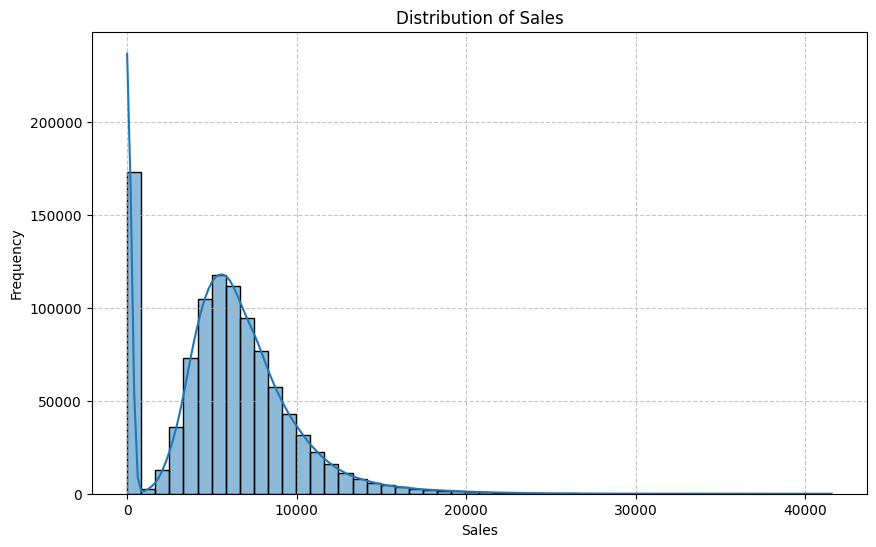

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Sales
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True, bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

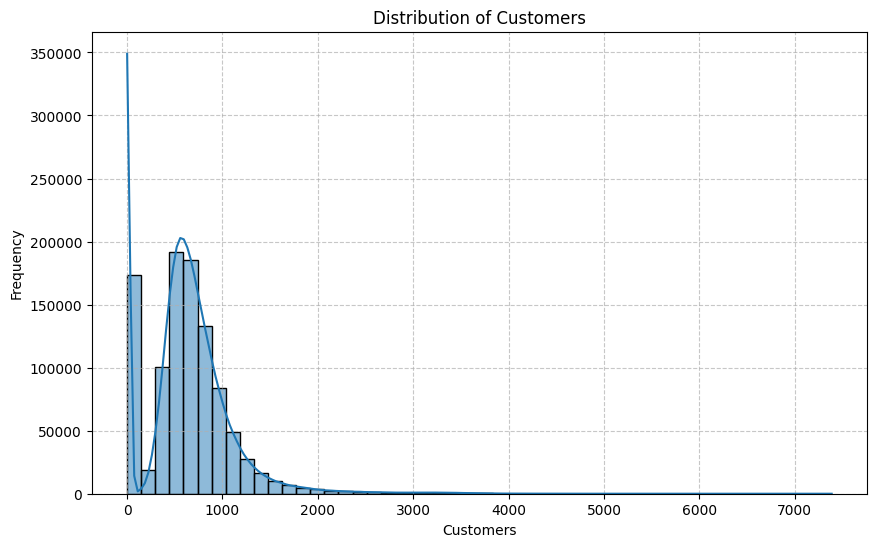

In [15]:
# Distribution of Customers
plt.figure(figsize=(10, 6))
sns.histplot(df['Customers'], kde=True, bins=50)
plt.title('Distribution of Customers')
plt.xlabel('Customers')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

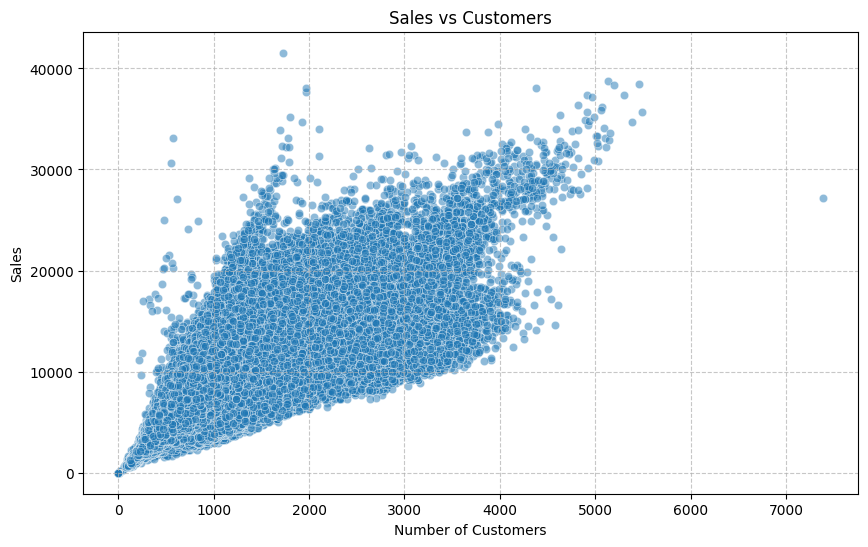

In [16]:
# Sales vs Customers
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Customers', y='Sales', data=df, alpha=0.5)
plt.title('Sales vs Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

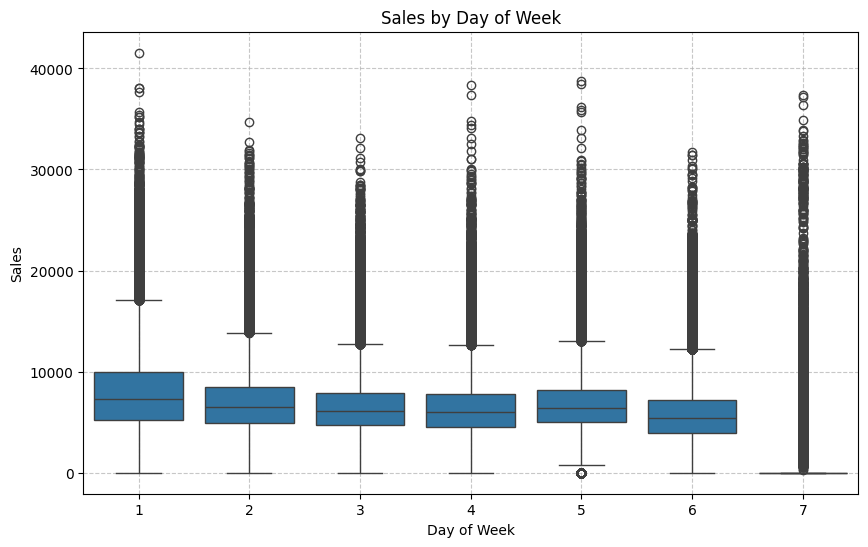

In [17]:
# Sales by Day of Week
plt.figure(figsize=(10, 6))
sns.boxplot(x='DayOfWeek', y='Sales', data=df)
plt.title('Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

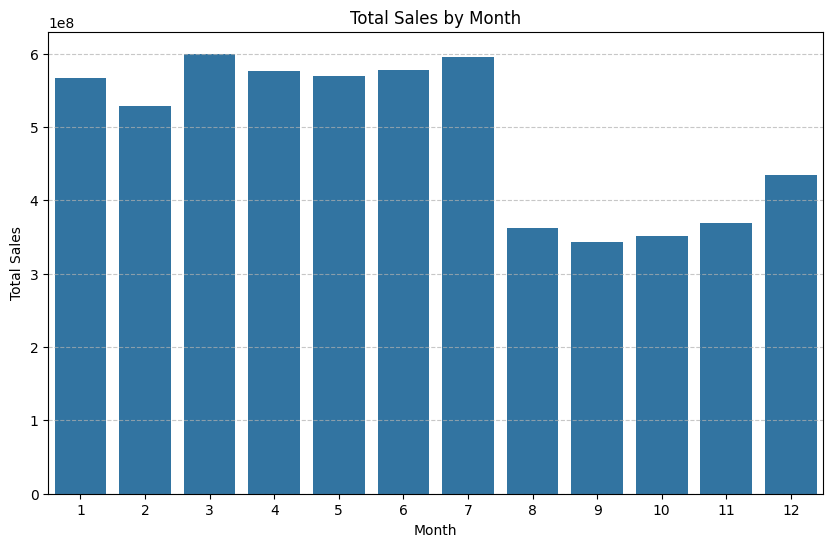

In [18]:
# Sales by Month
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Sales', data=monthly_sales)
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

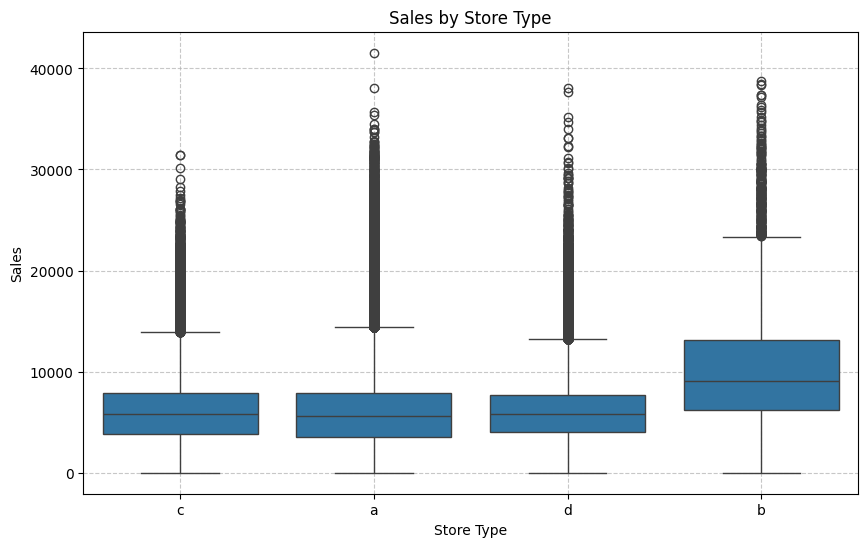

In [19]:
# Sales by StoreType
plt.figure(figsize=(10, 6))
sns.boxplot(x='StoreType', y='Sales', data=df)
plt.title('Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

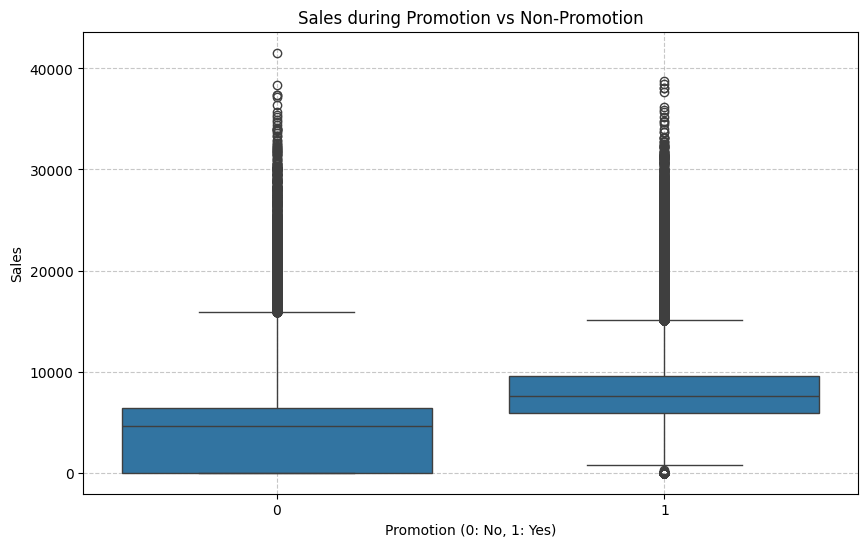

In [20]:
# Sales by Promo
plt.figure(figsize=(10, 6))
sns.boxplot(x='Promo', y='Sales', data=df)
plt.title('Sales during Promotion vs Non-Promotion')
plt.xlabel('Promotion (0: No, 1: Yes)')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

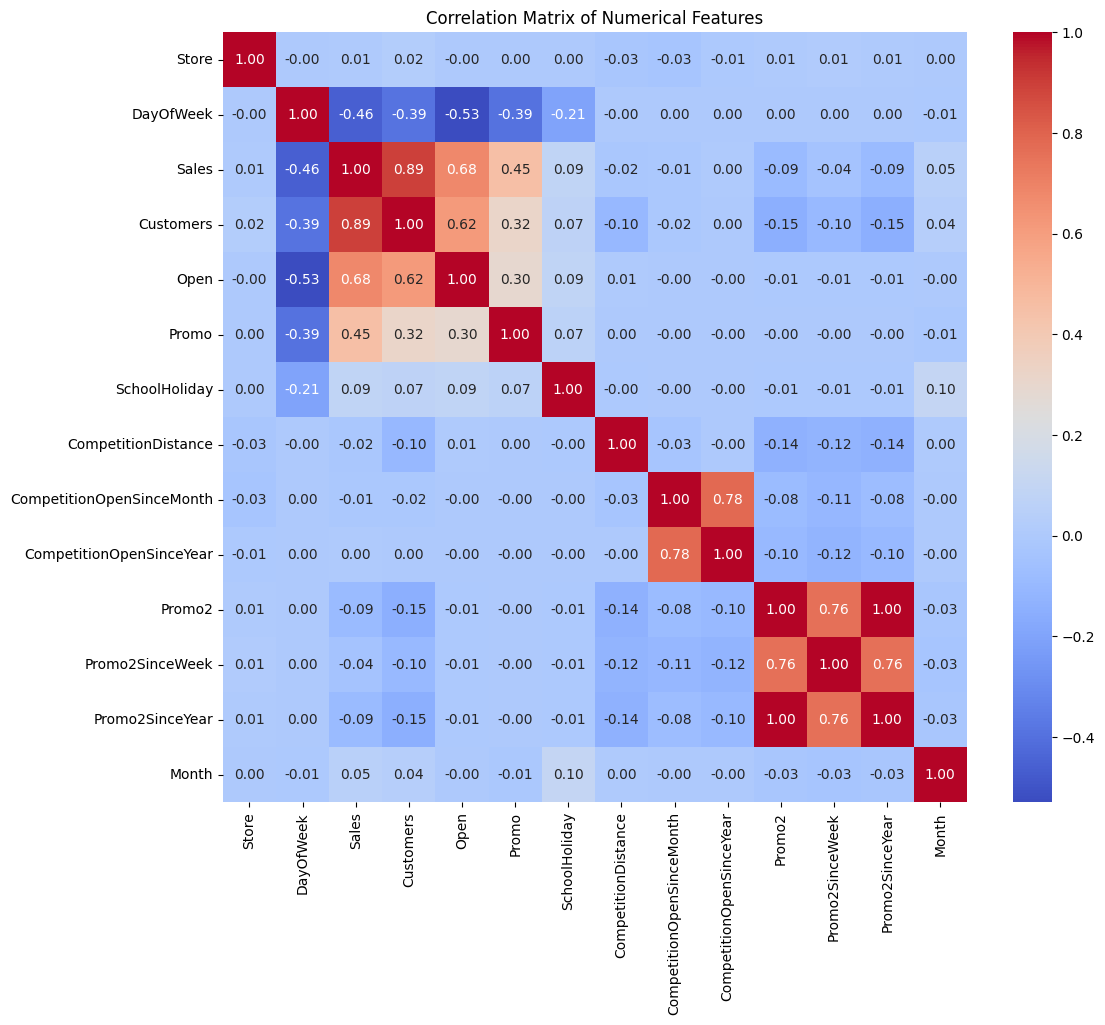

In [21]:
# Correlation matrix of numerical features
plt.figure(figsize=(12, 10))
numerical_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Feature engineering

In [22]:
df["competition_open_months"] = (
    (df["Date"].dt.year - df["CompetitionOpenSinceYear"]) * 12 + df["Date"].dt.month - df["CompetitionOpenSinceMonth"]).clip(lower=0)

In [23]:
promo_start = pd.to_datetime(
    df["Promo2SinceYear"].fillna(0).astype(int).astype(str)
    + "-"
    + df["Promo2SinceWeek"].fillna(0).astype(int).astype(str)
    + "-1",
    format="%Y-%W-%w",
    errors="coerce"
)

df["promo2_running_weeks"] = (
    (df["Date"] - promo_start)
    .dt.days
    .floordiv(7)
    .clip(lower=0)
    .fillna(0)
)

In [24]:
df["Month"] = df["Date"].dt.month
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsWeekend"] = (df["DayOfWeek"] >= 6).astype(int)
df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

In [25]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar",
    4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sept",
    10: "Oct", 11: "Nov", 12: "Dec"
}

df["IsPromoMonth"] = (
    df.apply(
        lambda x:
        1 if pd.notna(x["PromoInterval"])
        and month_map[x["Month"]] in str(x["PromoInterval"])
        else 0,
        axis=1,
    )
)

In [26]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Month', 'competition_open_months',
       'promo2_running_weeks', 'WeekOfYear', 'IsWeekend', 'IsMonthEnd',
       'IsPromoMonth'],
      dtype='object')

#### Seasonality,Trend and Stationary

In [27]:
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss

df['Date'] = pd.to_datetime(df['Date'])

df_open = df.sort_values(['Store', 'Date'])

store_sales = (
    df_open.groupby('Store')['Sales']
    .mean()
    .sort_values()
)

low_store = store_sales.index[0]
mid_store = store_sales.index[len(store_sales)-6//2]
high_store = store_sales.index[4]

stores = [low_store, mid_store, high_store]

print(stores)

[np.int64(307), np.int64(562), np.int64(841)]


##### STL decomposition

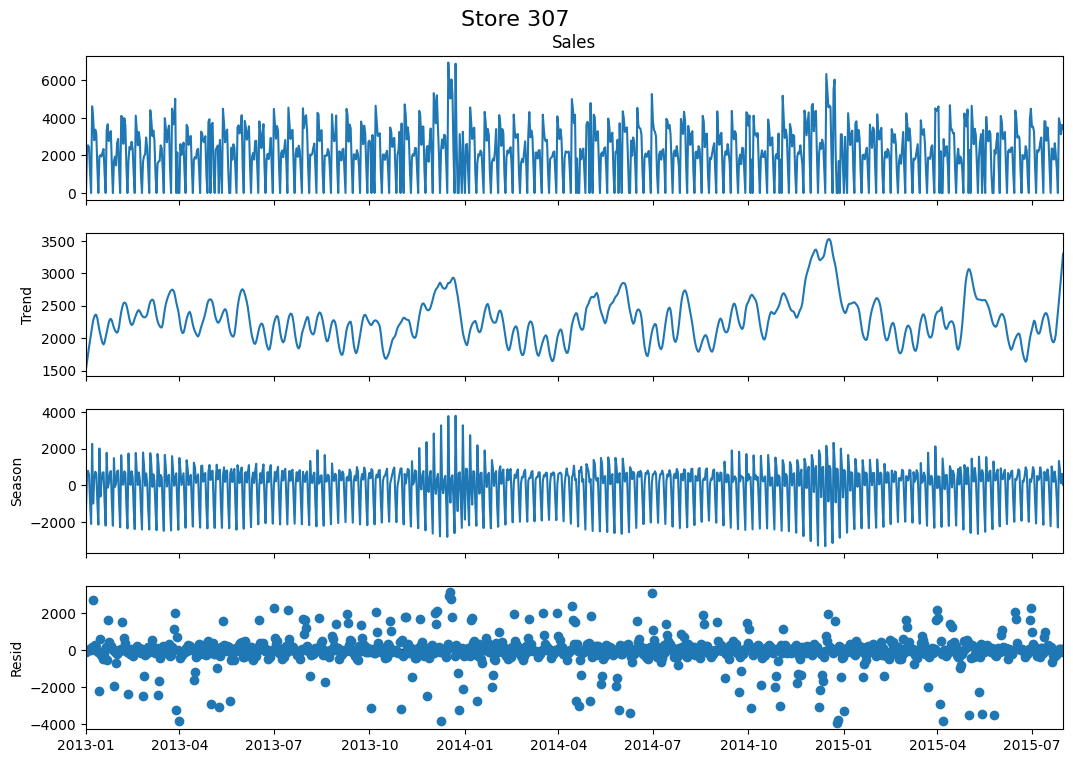

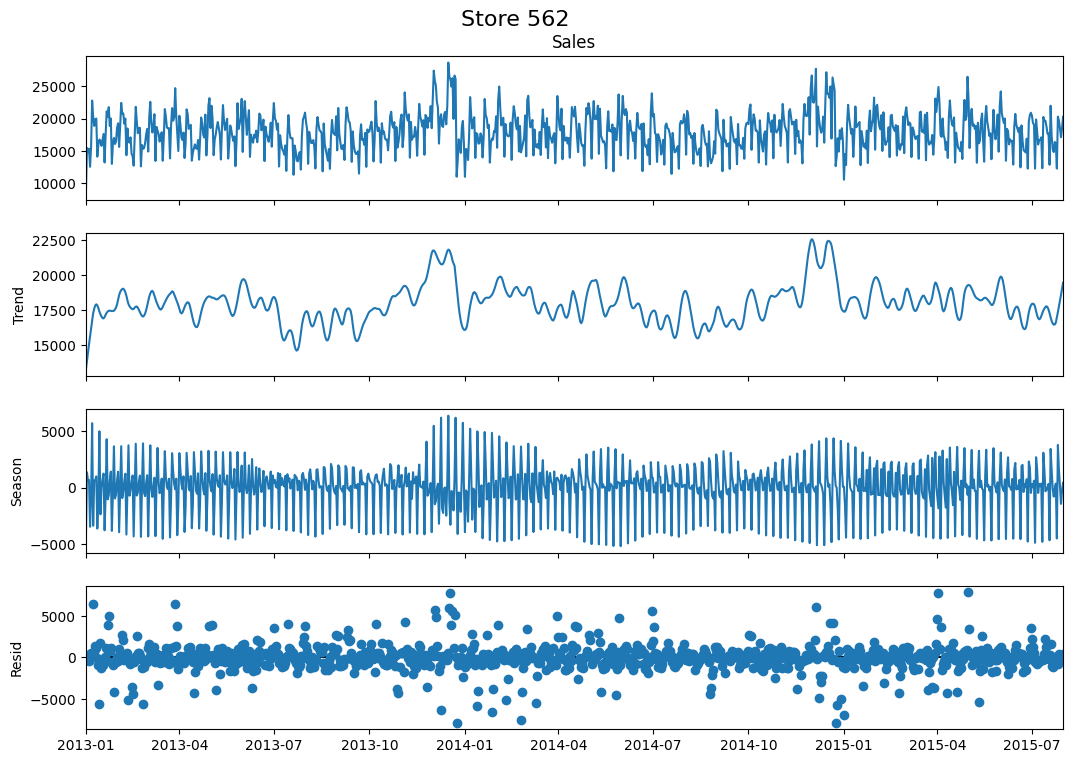

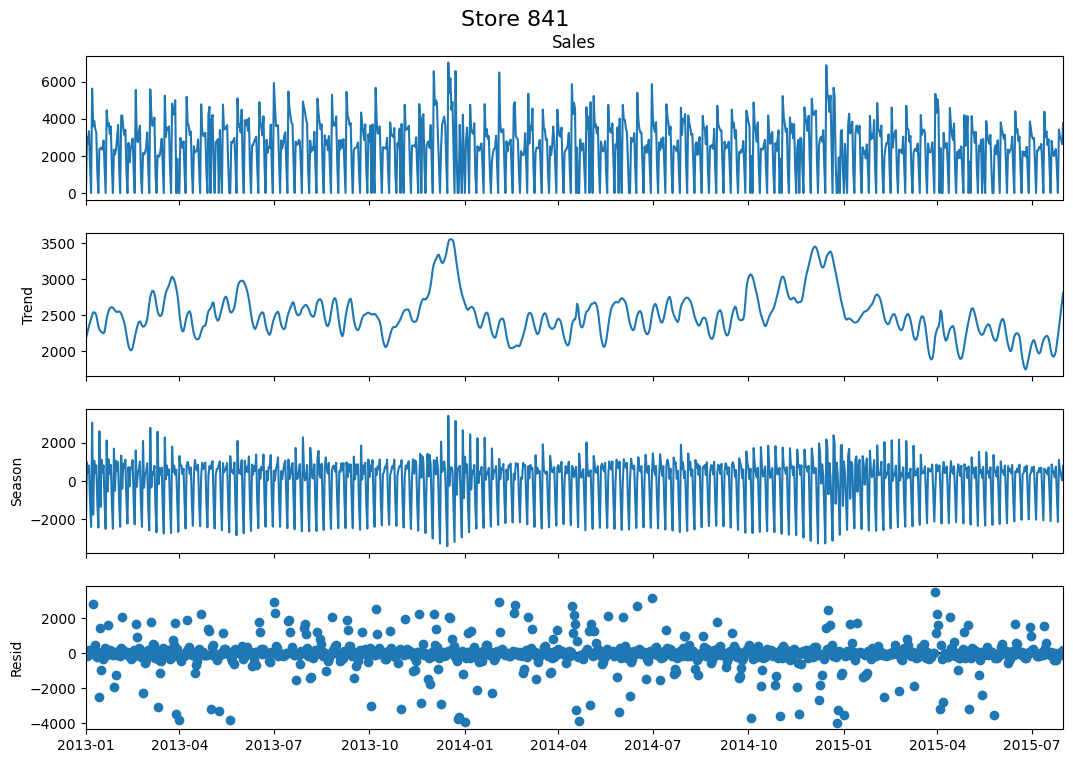

In [28]:
for store in stores:

    ts = (
        df_open[df_open['Store'] == store]
        .sort_values('Date')
        .set_index('Date')['Sales']
    )

    stl = STL(
        ts,
        period=7,
        robust=True
    )

    res = stl.fit()

    fig = res.plot()
    fig.set_size_inches(12,8)

    plt.suptitle(f"Store {store}", fontsize=16)
    plt.show()

##### ACF plots

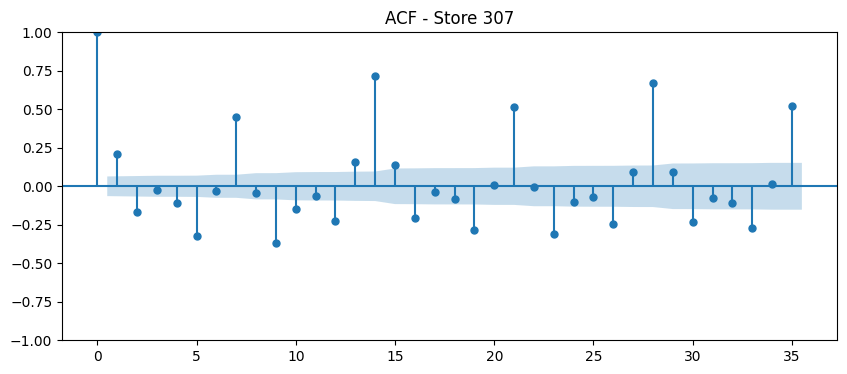

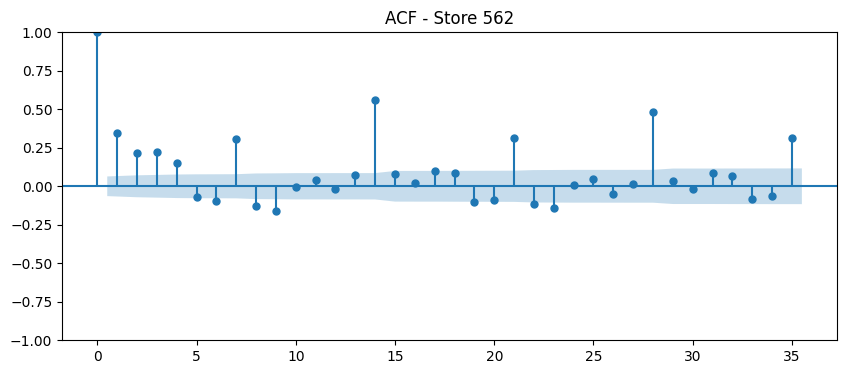

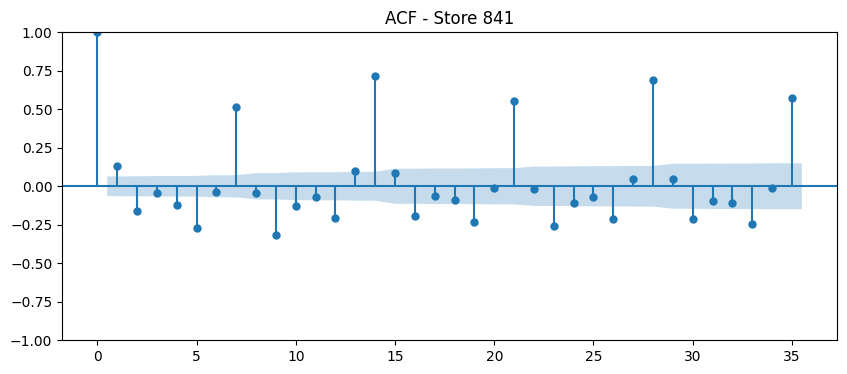

In [29]:
for store in stores:

    ts = (
        df_open[df_open['Store']==store]
        .sort_values('Date')
        .set_index('Date')['Sales']
    )

    plt.figure(figsize=(10,4))

    plot_acf(
        ts,
        lags=35,
        ax=plt.gca()
    )

    plt.title(f"ACF - Store {store}")
    plt.show()

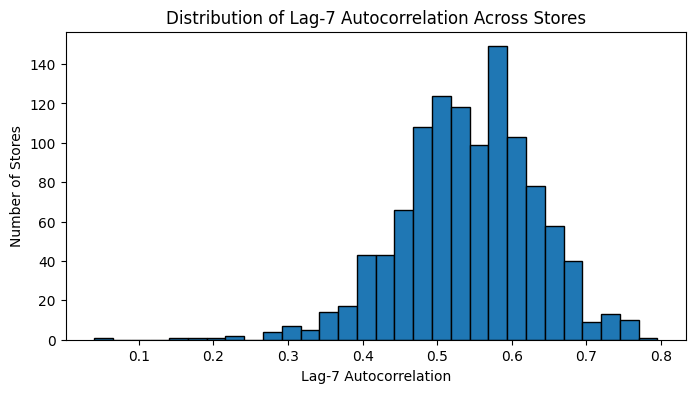

In [30]:
lag7 = []

for store, g in df.groupby("Store"):
    ts = g.sort_values("Date")["Sales"]
    lag7.append(ts.autocorr(lag=7))

plt.figure(figsize=(8, 4))
plt.hist(lag7, bins=30, edgecolor="black")
plt.xlabel("Lag-7 Autocorrelation")
plt.ylabel("Number of Stores")
plt.title("Distribution of Lag-7 Autocorrelation Across Stores")
plt.show()

#### Seasonal Naive(baseline)

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

df_SN = df.copy()
df_SN = df_SN.sort_values(['Date', 'Store'])

In [32]:
def rmspe(y_true, y_pred):
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return np.sqrt(
        np.mean(
            ((y_true - y_pred) / y_true) ** 2
        )
    )

In [33]:
def smape(y_true, y_pred):
    mask = y_true != 0

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    denominator = (
        np.abs(y_true) + np.abs(y_pred)
    ) / 2

    mask2 = denominator != 0

    return (
        np.mean(
            np.abs(y_true[mask2] - y_pred[mask2])
            / denominator[mask2]
        )
        * 100
    )

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

season_length = 7  # Weekly seasonality

unique_dates = np.sort(df_SN["Date"].unique())
tscv = TimeSeriesSplit(n_splits=3)

fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_dates), start=1):

    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]

    train_df = df_SN[df_SN["Date"].isin(train_dates)]
    test_df = df_SN[df_SN["Date"].isin(test_dates)]

    # History available at the forecast origin
    history = pd.concat([train_df["Sales"], test_df["Sales"]], ignore_index=True)

    # Seasonal naive forecasts
    y_pred = history.shift(season_length).iloc[len(train_df):].to_numpy()
    y_test = test_df["Sales"].to_numpy()

    # Remove missing predictions (if any)
    valid = ~np.isnan(y_pred)
    y_test = y_test[valid]
    y_pred = y_pred[valid]

    fold_metrics.append({
        "fold": fold,
        "rmspe": rmspe(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
        "smape": smape(y_test, y_pred)
    })

results_SN = pd.DataFrame(fold_metrics)

print("\n========== Seasonal Naive Cross Validation Results ==========")
print(results_SN)

print("\n========== Consistency ==========")

for metric in ['mae', 'rmspe', 'smape']:
    mean_val = results_SN[metric].mean()
    std_val = results_SN[metric].std()
    cv = (std_val / mean_val) * 100

    print(f"{metric.upper()}")
    print(f"  Mean : {mean_val:.3f}")
    print(f"  Std  : {std_val:.3f}")
    print(f"  CV   : {cv:.2f}%\n")


print("\n========== Mean Performance ==========")
print(f"Mean RMSPE : {results_SN['rmspe'].mean():.3f}")
print(f"Mean MAE   : {results_SN['mae'].mean():.2f}")
print(f"Mean SMAPE : {results_SN['smape'].mean():.2f}%")


========== Seasonal Naive Cross Validation Results ==========
   fold     rmspe          mae      smape
0     1  0.657849  2356.242687  39.032938
1     2  0.679394  2332.750816  38.967698
2     3  0.677053  2362.995122  38.518219

========== Consistency ==========
MAE
  Mean : 2350.663
  Std  : 15.875
  CV   : 0.68%

RMSPE
  Mean : 0.671
  Std  : 0.012
  CV   : 1.76%

SMAPE
  Mean : 38.840
  Std  : 0.280
  CV   : 0.72%


========== Mean Performance ==========
Mean RMSPE : 0.671
Mean MAE   : 2350.66
Mean SMAPE : 38.84%


#### XG Boost

In [35]:
# Lag features for Demand Forecast
df_xgb = df.copy()

df_xgb = df_xgb.sort_values(['Date', 'Store'])

lags = [1,7, 14, 28]  # daily, weekly, monthly

for lag in lags:
    df_xgb[f'demand_lag_{lag}'] = df_xgb.groupby(['Store'])['Sales'].transform(lambda x: x.shift(lag))
    df_xgb[f'rolling_mean_{lag}'] = df_xgb.groupby(['Store'])['Sales'].transform(lambda x: x.shift(1).rolling(lag).mean())
    df_xgb[f'rolling_std_{lag}'] = df_xgb.groupby(['Store'])['Sales'].transform(lambda x: x.shift(1).rolling(lag).std())

In [36]:
# Filter out rows where any of the lag or rolling features are NaN.
df_xgb.dropna(subset=[f'demand_lag_{lags[-1]}', f'rolling_mean_{lags[-1]}', f'rolling_std_{lags[-1]}'], inplace=True)

In [37]:
# Ensure Date column is datetime
df_xgb['Date'] = pd.to_datetime(df_xgb['Date'])

# Day of week (0=Monday, 6=Sunday)
df_xgb['day_of_week'] = df_xgb['Date'].dt.dayofweek

# Month (1–12)
df_xgb['month'] = df_xgb['Date'].dt.month

# Identify categorical columns to encode
categorical_features = df_xgb.select_dtypes(include='object').columns.tolist()

# One-hot encode categorical features
df_xgb = pd.get_dummies(df_xgb, columns=categorical_features, drop_first=True)

##### XGB Training

In [38]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Base model (using default hyperparameters as requested)
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1 # Use all available cores for training
)

# Define features (X) and target (y)
X = df_xgb.drop(columns=['Date', 'Sales', 'Customers','Open'])
y = df_xgb['Sales']

unique_dates = np.sort(df_xgb["Date"].unique())

tscv = TimeSeriesSplit(n_splits=3)

fold_metrics_xgb = []
all_xgb_actuals = []
all_xgb_preds = []
all_xgb_residuals = []

# Perform TimeSeriesSplit on the global dataset using default parameters
for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_dates), start=1):
    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]

    print(f"\nFold {fold}")
    print("Train:", train_dates.min(), "to", train_dates.max())
    print("Test :", test_dates.min(), "to", test_dates.max())

    train_mask = df_xgb["Date"].isin(train_dates)
    test_mask = df_xgb["Date"].isin(test_dates)

    
    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    # Train the model for the current fold with default XGBoost parameters
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # Make predictions and calculate metrics for the current fold
    y_pred = model.predict(X_test)

    residuals = y_test.values - y_pred

    all_xgb_residuals.extend(residuals)
    all_xgb_preds.extend(y_pred)
    all_xgb_actuals.extend(y_test.values)

    # Calculate metrics using the defined rmspe and smape functions
    rmspe_val = rmspe(y_test, y_pred) # Using the custom rmspe function
    mae = mean_absolute_error(y_test, y_pred)
    smape_val = smape(y_test, y_pred) # Using the custom smape function

    fold_metrics_xgb.append({
        'fold': fold,
        'rmspe': rmspe_val,
        'mae': mae,
        'smape': smape_val
    })

results_xgb = pd.DataFrame(fold_metrics_xgb)

print("\n========== Consistency ==========")

for metric in ['mae', 'rmspe', 'smape']:
    mean_val = results_xgb[metric].mean()
    std_val = results_xgb[metric].std()
    cv = (std_val / mean_val) * 100

    print(f"{metric.upper()}")
    print(f"  Mean : {mean_val:.3f}")
    print(f"  Std  : {std_val:.3f}")
    print(f"  CV   : {cv:.2f}%\n")

print("\n========== XGB Cross Validation Results ==========")
print(results_xgb)

print("\n========== Mean Performance ==========")
print(f"Mean RMSPE : {results_xgb['rmspe'].mean():.3f}")
print(f"Mean MAE   : {results_xgb['mae'].mean():.2f}")
print(f"Mean SMAPE : {results_xgb['smape'].mean():.2f}%")


Fold 1
Train: 2013-01-29T00:00:00.000000000 to 2013-09-15T00:00:00.000000000
Test : 2013-09-16T00:00:00.000000000 to 2014-05-01T00:00:00.000000000

Fold 2
Train: 2013-01-29T00:00:00.000000000 to 2014-05-01T00:00:00.000000000
Test : 2014-05-02T00:00:00.000000000 to 2014-12-15T00:00:00.000000000

Fold 3
Train: 2013-01-29T00:00:00.000000000 to 2014-12-15T00:00:00.000000000
Test : 2014-12-16T00:00:00.000000000 to 2015-07-31T00:00:00.000000000

========== Consistency ==========
MAE
  Mean : 1089.920
  Std  : 748.845
  CV   : 68.71%

RMSPE
  Mean : 0.319
  Std  : 0.166
  CV   : 52.06%

SMAPE
  Mean : 24.152
  Std  : 23.369
  CV   : 96.76%


========== XGB Cross Validation Results ==========
   fold     rmspe          mae      smape
0     1  0.495478  1953.982300  51.127862
1     2  0.293333   686.443298  11.245205
2     3  0.166712   629.333435  10.083736

========== Mean Performance ==========
Mean RMSPE : 0.319
Mean MAE   : 1089.92
Mean SMAPE : 24.15%


##### Feature Importance

Top 10 Feature Importances:


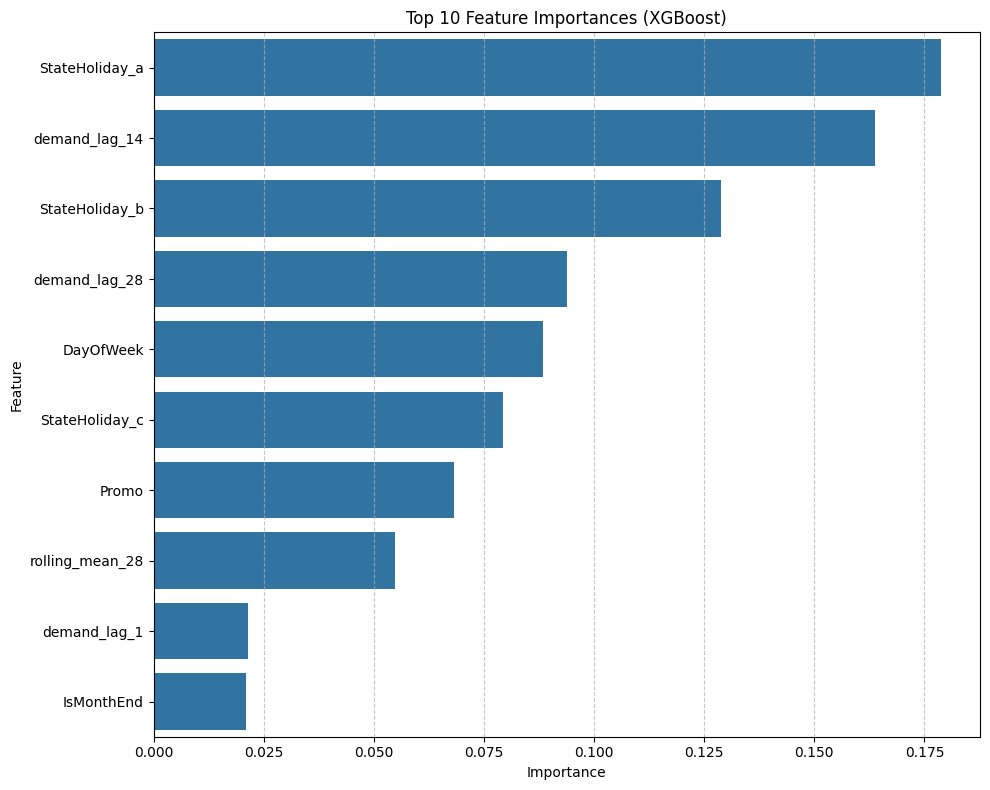

In [39]:
    feature_importances = model.feature_importances_

    # Get feature names from the training data X
    feature_names = X.columns

    # Create a pandas Series for easier handling and sorting
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    print("Top 10 Feature Importances:")
    importance_df.head(10)

    # Plotting feature importances
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
    plt.title('Top 10 Feature Importances (XGBoost)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

##### Residual plots

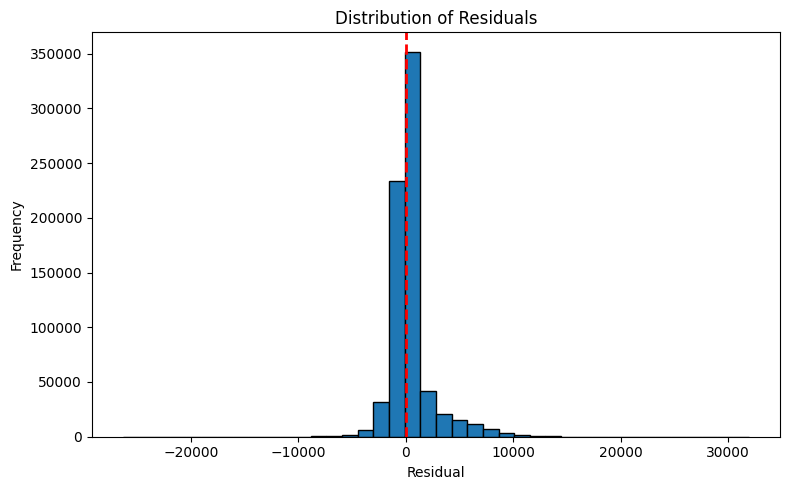

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(all_xgb_residuals,
         bins=40,
         edgecolor='black')

plt.axvline(0,
            color='red',
            linestyle='--',
            linewidth=2)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

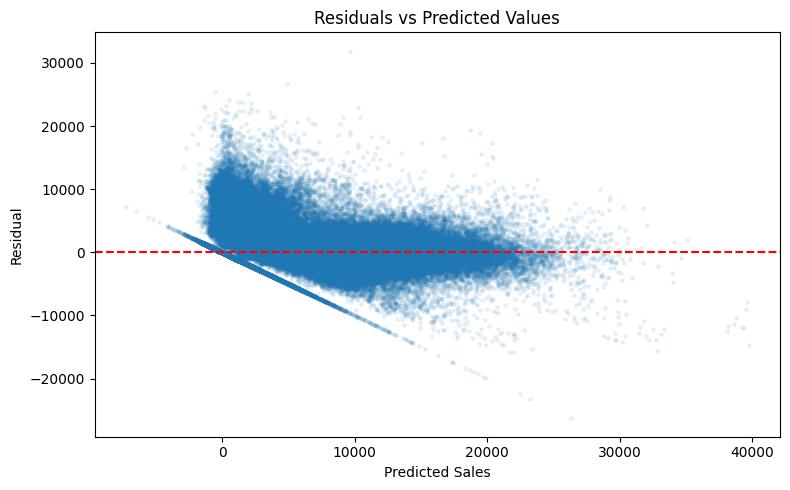

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(all_xgb_preds,
            all_xgb_residuals,
            s=6,
            alpha=0.08)

plt.axhline(0,
            color='red',
            linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.tight_layout()
plt.show()

##### Q-Q plot

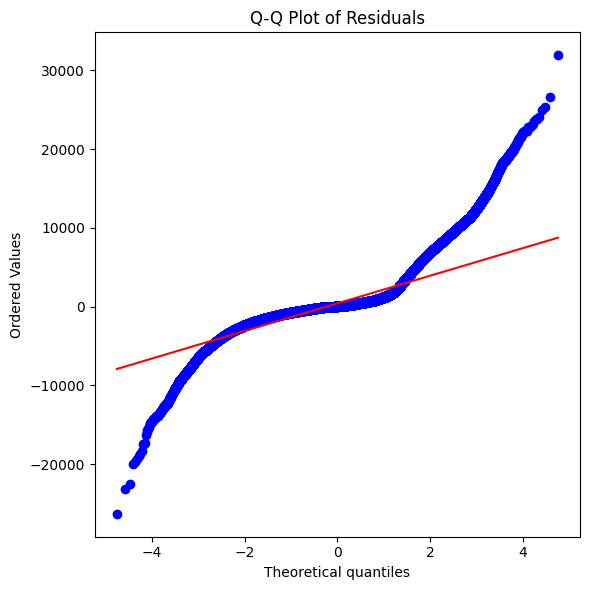

In [42]:
import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(all_xgb_residuals,
               dist="norm",
               plot=plt)

plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

#### Temporal Fusion transformer(TFT)

In [43]:
!pip install -q pytorch-lightning pytorch-forecasting lightning torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 10.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 9.5 MB/s eta 0:00:00


In [44]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [45]:
import torch
import lightning.pytorch as pl
from pytorch_forecasting import(TimeSeriesDataSet, TemporalFusionTransformer)
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

In [46]:
df_tft = df.copy(deep=True)

In [47]:
df_tft.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 1016095 to 1114
Data columns (total 25 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1017209 non-

##### Feature engineering

In [48]:
df_tft = df_tft.sort_values(["Date", "Store"])
df_tft["time_idx"] = df_tft.groupby("Store").cumcount().astype("int32")


In [49]:
store = df_tft["Store"].iloc[0]
print(store)

df_tft[df_tft["Store"] == store][["Date", "time_idx"]].head(20)

1


,Date,time_idx
1016095,2013-01-01,0
1014980,2013-01-02,1
1013865,2013-01-03,2
1012750,2013-01-04,3
1011635,2013-01-05,4
1010520,2013-01-06,5
1009405,2013-01-07,6
1008290,2013-01-08,7
1007175,2013-01-09,8
1006060,2013-01-10,9


In [50]:
cate_cols = [
    "Store",
    "Open",
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "StoreType",
    "Assortment",
    "Promo2",
    "PromoInterval",
    "IsWeekend",
    "IsMonthEnd",
    "IsPromoMonth"
]

for col in cate_cols:
    df_tft[col] = df_tft[col].astype(str).astype("category")

In [51]:
df_tft["Sales"] = df_tft["Sales"].astype(float)

##### Data preprocessing

In [52]:
static_categoricals = [
    "Store",
    "StoreType",
    "Assortment",
    "Promo2"]

static_reals = ["CompetitionDistance"]

time_varying_known_categoricals = [
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "Open",
    "IsWeekend",
    "IsMonthEnd",
    "IsPromoMonth"
]

time_varying_known_reals = [
    "time_idx",
    "Month",
    "DayOfWeek",
    "WeekOfYear",
    "competition_open_months",
    "promo2_running_weeks"
]

time_varying_unknown_reals = [
    "Sales"
]

df_tft = df_tft.drop(
    columns=[
        "Customers",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "Promo2SinceWeek",
        "Promo2SinceYear"
    ]
)

##### Building Time series datset

In [53]:
from pytorch_forecasting.data.encoders import NaNLabelEncoder

def create_tft_dataset(df):
    return TimeSeriesDataSet(
        df,
        time_idx="time_idx",
        target="Sales",
        group_ids=["Store"],
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        categorical_encoders = {"StateHoliday": NaNLabelEncoder(add_nan=True)},
        static_categoricals=static_categoricals,
        static_reals=static_reals,
        time_varying_known_categoricals=time_varying_known_categoricals,
        time_varying_known_reals=time_varying_known_reals,
        time_varying_unknown_reals=time_varying_unknown_reals,
        target_normalizer=GroupNormalizer(groups=["Store"]),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

In [54]:
from sklearn.model_selection import TimeSeriesSplit

max_encoder_length = 90
max_prediction_length = 28

unique_dates = np.sort(df_tft["Date"].unique())

folds = []
tscv = TimeSeriesSplit(n_splits=3)

for fold, (train_idx, val_idx) in enumerate(tscv.split(unique_dates), start=1):

    train_dates = unique_dates[train_idx]
    val_dates = unique_dates[val_idx]

    print(f"\nFold {fold}")
    print("Train:", train_dates.min(), "to", train_dates.max())
    print("Test :", val_dates.min(), "to", val_dates.max())

    train_tft = df_tft[df_tft["Date"].isin(train_dates)].copy()
    test_tft = df_tft[df_tft["Date"].isin(val_dates)].copy()

    train_tft = train_tft.sort_values(["Date", "Store"])
    test_tft = test_tft.sort_values(["Date", "Store"])

    train_tft = train_tft.drop(columns=["Date"])
    test_tft = test_tft.drop(columns=["Date"])

    train = create_tft_dataset(train_tft)

    test = TimeSeriesDataSet.from_dataset(
        train,
        test_tft,
        predict=False,
        stop_randomization=True,
    )
    print("train", len(train))
    print("test", len(test))

    folds.append((train, test))


Fold 1
Train: 2013-01-01T00:00:00.000000000 to 2013-08-25T00:00:00.000000000
Test : 2013-08-26T00:00:00.000000000 to 2014-04-17T00:00:00.000000000


/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/encoders.py:402: UserWarning: Found 1 unknown classes which were set to NaN
  warnings.warn(


train 133799
test 131570

Fold 2
Train: 2013-01-01T00:00:00.000000000 to 2014-04-17T00:00:00.000000000
Test : 2014-04-18T00:00:00.000000000 to 2014-12-08T00:00:00.000000000


/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 180 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__Store': '100'}, {'__group_id__Store': '1000'}, {'__group_id__Store': '1004'}, {'__group_id__Store': '1009'}, {'__group_id__Store': '1012'}, {'__group_id__Store': '1019'}, {'__group_id__Store': '1027'}, {'__group_id__Store': '1038'}, {'__group_id__Store': '1041'}, {'__group_id__Store': '1049'}]
  warnings.warn(


train 395824
test 110330

Fold 3
Train: 2013-01-01T00:00:00.000000000 to 2014-12-08T00:00:00.000000000
Test : 2014-12-09T00:00:00.000000000 to 2015-07-31T00:00:00.000000000
train 628869
test 127430


##### Buiolding data loaders

##### Training TFT

In [55]:
def build_tft(train):

    tft = TemporalFusionTransformer.from_dataset(
        train,
        learning_rate=1e-3,
        hidden_size=32,
        attention_head_size=4,
        hidden_continuous_size=16,
        lstm_layers=1,
        dropout=0.1,
        loss=QuantileLoss(),
        reduce_on_plateau_patience=4,
        log_interval=-1,
        log_val_interval=-1,
    )

    return tft

In [56]:
def train_fold(train, train_dataloader, test_dataloader, max_epochs=15):
  model = build_tft(train)
  early_stop = EarlyStopping(
      monitor="val_loss",
      min_delta=1e-4,
      patience=4,
      verbose=True,
      mode="min"
  )

  trainer = pl.Trainer(
      max_epochs=max_epochs,
      accelerator="gpu",
      devices=1,
      enable_model_summary=True,
      precision="32",
      gradient_clip_val =0.1,
      callbacks = [early_stop],
      enable_progress_bar=True,
      enable_checkpointing=True,
      logger= False
  )

  trainer.fit(
      model,
      train_dataloaders=train_dataloader,
      val_dataloaders=test_dataloader
  )

  return model, trainer

In [57]:
fold_metrics = []
all_tft_actuals=[]
all_tft_residuals=[]
all_tft_preds=[]

for fold, (train, test) in enumerate(folds, start=1):

    print(f"\n{'='*60}")
    print(f"Training Fold {fold}")
    print(f"{'='*60}")

    # DataLoaders
    train_dataloader = train.to_dataloader(
        train=True,
        batch_size=2048,
        num_workers=4,
        persistent_workers=True,
    )

    test_dataloader = test.to_dataloader(
        train=False,
        batch_size=4096,
        num_workers=4,
        persistent_workers=True,
    )

    # Train model
    model, trainer = train_fold(
        train,
        train_dataloader,
        test_dataloader,
        max_epochs=15,
    )

    # Predictions
    predictions = model.predict(
        test_dataloader,
        mode="prediction",
        trainer_kwargs={"accelerator": "gpu", "devices": 1},
    )

    actuals = torch.cat([y[0] for _, y in test_dataloader])

    y_pred = predictions.cpu().numpy().ravel()
    y_true = actuals.cpu().numpy().ravel()

    residuals = y_true - y_pred

    all_tft_residuals.extend(residuals)
    all_tft_preds.extend(y_pred)
    all_tft_actuals.extend(y_true)


    # Metrics
    rmspe_score = rmspe(y_true, y_pred)
    mae_score = mean_absolute_error(y_true, y_pred)
    smape_score = smape(y_true, y_pred)

    print(f"\nFold {fold} Results")
    print(f"RMSPE : {rmspe_score:.3f}")
    print(f"MAE   : {mae_score:.2f}")
    print(f"SMAPE : {smape_score:.2f}%")

    fold_metrics.append({
        "Fold": fold,
        "RMSPE": rmspe_score,
        "MAE": mae_score,
        "SMAPE": smape_score,
    })

# Summary
results_tft = pd.DataFrame(fold_metrics)

print("\n========== Consistency ==========")

for metric in ['MAE', 'RMSPE', 'SMAPE']:
    mean_val = results_tft[metric].mean()
    std_val = results_tft[metric].std()
    cv = (std_val / mean_val) * 100

    print(f"{metric.upper()}")
    print(f"  Mean : {mean_val:.3f}")
    print(f"  Std  : {std_val:.3f}")
    print(f"  CV   : {cv:.2f}%\n")

print("\n========== TFT Cross Validation Results ==========")
print(results_tft)

print("\n========== Mean Performance ==========")
print(f"Mean RMSPE : {results_tft['RMSPE'].mean():.3f}")
print(f"Mean MAE   : {results_tft['MAE'].mean():.2f}")
print(f"Mean SMAPE : {results_tft['SMAPE'].mean():.2f}%")


Training Fold 1


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which 

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │ 35.7 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    384 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  8.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 18.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 16.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 132 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 132 K                                                                                                
Total estimated model params size (MB): 0.529                                                                      
Modules in train mode: 521                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Metric val_loss improved. New best score: 460.744
Metric val_loss improved by 132.341 >= min_delta = 0.0001. New best score: 328.402
Metric val_loss improved by 3.531 >= min_delta = 0.0001. New best score: 324.871
Metric val_loss improved by 0.689 >= min_delta = 0.0001. New best score: 324.182
Monitored metric val_loss did not improve in the last 4 records. Best score: 324.182. Signaling Trainer to stop.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784e7ea4f9c0>
Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784e7ea4f9c0>Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x784e7ea4f9c0>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):


Fold 3 Results
RMSPE : 0.142
MAE   : 597.46
SMAPE : 9.95%

========== Consistency ==========
MAE
  Mean : 871.010
  Std  : 375.809
  CV   : 43.15%

RMSPE
  Mean : 0.276
  Std  : 0.116
  CV   : 41.98%

SMAPE
  Mean : 13.634
  Std  : 5.065
  CV   : 37.15%


========== TFT Cross Validation Results ==========
   Fold     RMSPE          MAE      SMAPE
0     1  0.348500  1299.520752  19.411036
1     2  0.337666   716.049561  11.535942
2     3  0.142446   597.459290   9.954962

========== Mean Performance ==========
Mean RMSPE : 0.276
Mean MAE   : 871.01
Mean SMAPE : 13.63%


##### Residuals

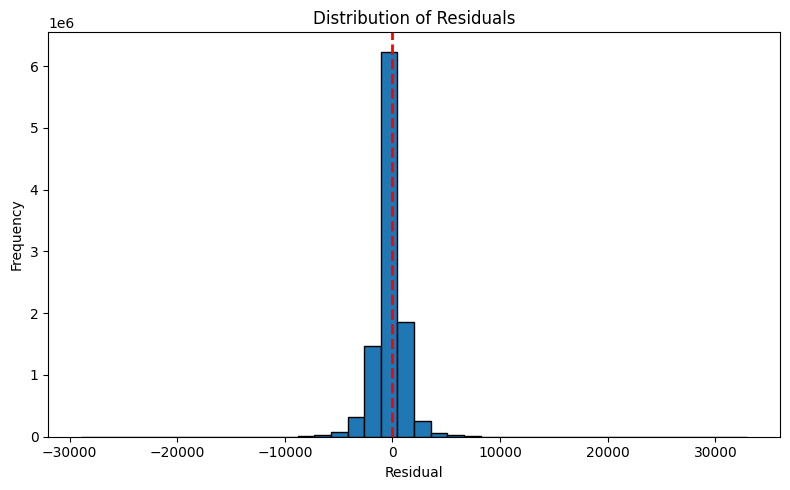

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(all_tft_residuals,
         bins=40,
         edgecolor='black')

plt.axvline(0,
            color='red',
            linestyle='--',
            linewidth=2)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

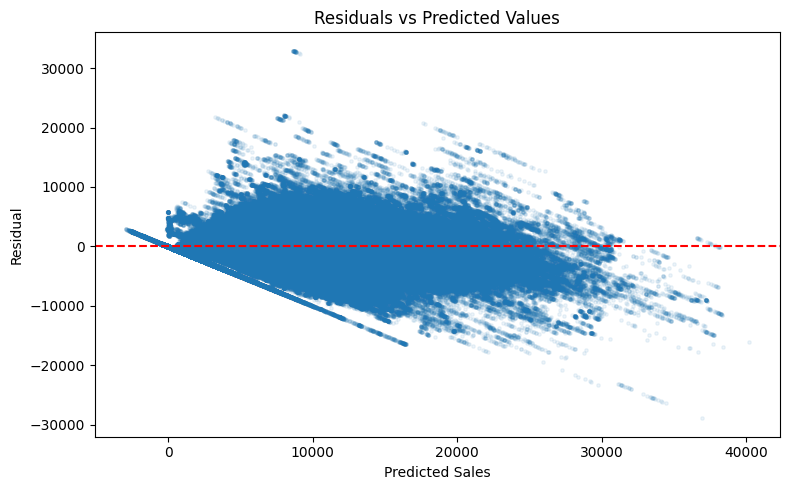

In [60]:
plt.figure(figsize=(8,5))

plt.scatter(all_tft_preds,
            all_tft_residuals,
            s=6,
            alpha=0.08)

plt.axhline(0,
            color='red',
            linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.tight_layout()
plt.show()

##### Q-Q plot

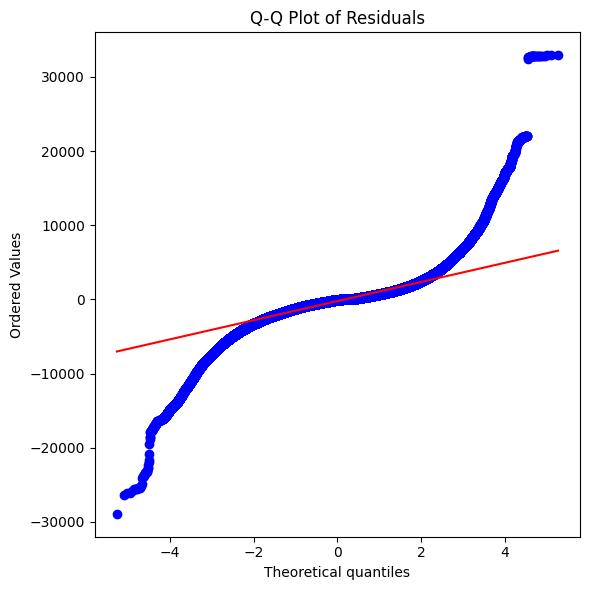

In [61]:
import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(all_tft_residuals,
               dist="norm",
               plot=plt)

plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

#### Validation

##### Boxplot

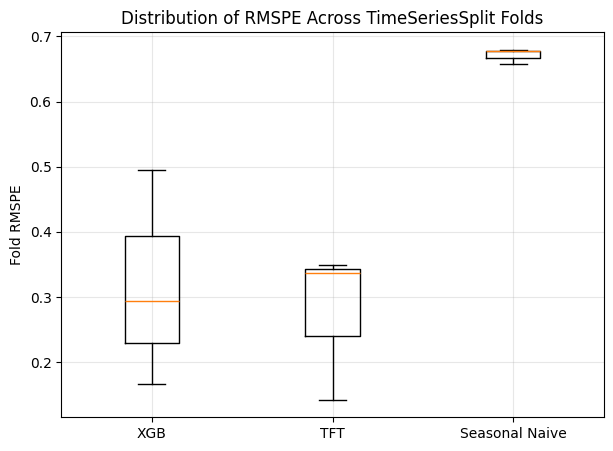

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.boxplot(
    [
        results_xgb['rmspe'],
        results_tft['RMSPE'],
        results_SN['rmspe']
    ],
    tick_labels=["XGB", "TFT", "Seasonal Naive"]
)

plt.ylabel("Fold RMSPE")
plt.title("Distribution of RMSPE Across TimeSeriesSplit Folds")

plt.grid(alpha=0.3)

plt.show()